In [1]:
### Hayden Gallo
### Bucci Lab 
### 7/29/26

### Here I want to test FVA using the AGORA models to see how long loopless FVA takes vs FVA vs flux sampling for the AGORA models for Venturelli 

import numpy as np
import pandas as pd
import cobra
import seaborn as sns
import matplotlib.pyplot as plt
import math
import time
from tqdm import tqdm 
import os 
import gurobipy
from pathlib import Path

from helper_functions import *




In [2]:
allspecies=['ER','FP','AC','CC','RI','EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA']


namedict={
   'BA': 'Bifidobacterium_adolescentis_ATCC_15703_NC_008618',
   'CA': 'Collinsella_aerofaciens_ATCC_25986',
   'BT': 'Bacteroides_thetaiotaomicron_VPI-5482_NC_004663',
   'BU': 'Bacteroides_uniformis_ATCC_8492',
   'PC': 'Prevotella_copri_DSM_18205',
   'AC': 'Anaerostipes_caccae_DSM_14662_4',
   'BH': 'Blautia_hydrogenotrophica_DSM_10507',
   'CC': 'Coprococcus_comes_1.0.1_Cont2276_NZ_ABVR01000038',
   'CG': 'Clostridium_asparagiforme_DSM_15981_C_asparagiforme_1.0_Cont7.2_NZ_ACCJ01000522',
   'ER': 'Eubacterium_rectale_ATCC_33656_NC_012781',
   'DP': 'Desulfovibrio_piger_ATCC_29098',
   'EL': 'Eggerthella_lenta_DSM_2243_NC_013204',
   'BY': 'Bacteroides_cellulosilyticus_DSM_14838_1.0_Cont4.1_NZ_ACCH01000108',
   'BF': 'Bacteroides_fragilis_NCTC_9343',
   'CD': 'Clostridioides_difficile',
   'RI': 'Roseburia_intestinalis_L1_82',
   'BP': 'Bifidobacterium_pseudocatenulatum_DSM20438',
   'BV': 'Bacteroides_vulgatus_ATCC_8482_NC_009614',
   'CH': 'Clostridium_hiranonis_DSM_13275',
   'DF': 'Dorea_formicigenerans_ATCC_27755',
   'CS': 'Clostridium_scindens_ATCC_35704',
   'PJ': 'Parabacteroides_johnsonii_DSM_18315_NZ_ABYH01000014',
   'FP': 'Faecalibacterium_prausnitzii_A2_165_NZ',
   'EH': 'Eubacterium_hallii_DSM_3353_1.0_Cont383.1_NZ_ACEP01000116',
   'EC': 'Escherichia_coli',
   'BC': 'Bacteroides_caccae_ATCC_43185',
   'HB': 'Holdemanella_biformis_DSM_3989',
   'BO': 'Bacteroides_ovatus_ATCC_8483',
   'DL': 'Dorea_longicatena_DSM_13814',
   'BL': 'Bifidobacterium_longum_subsp_infantis',
   'B.cereus':'Bacillus_cereus'
   }

In [3]:
### here is the path for the agora models

#data_dir = '/Users/haydengallo/UMass_Dropbox/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_data'
data_dir = '/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_data'
# directory for pan genus models 
cobra_models_dir_path = data_dir + '/panGenusModels_Venturelli_corrected'

cobra_models_dir = Path(cobra_models_dir_path)

In [4]:

cobra_models = sorted(cobra_models_dir.glob('*.mat'))
cobra_models = {f.stem : f for f in cobra_models}

### Just loading the models needed in 

loaded_models = {}

#count = 0

for key in cobra_models:
    #if count == 1:
    #    break
    #print(key.split('_'))
    model_name = key.split('_')[2] + '_' + key.split('_')[3]
    #model_name = key.split('.')[0]
    #model_name = model_name[3:]
    #print(model_name)
    model = cobra.io.load_matlab_model(cobra_models[key])
    loaded_models[model_name] = model
    #count+=1


adjusted_names = []

for key in namedict:
    temp = namedict[key].split('_')
    temp_name = temp[0] + '_' + temp[1]
    adjusted_names.append(temp_name)

adjusted_names_dict = dict(zip(namedict.keys(), adjusted_names))
reverse_order_name_dict = dict(zip(adjusted_names, namedict.keys()))

correct_model_dict_order = {}
correct_model_name_order = []


for i in allspecies:
    model_to_grab = adjusted_names_dict[i]
    #model_to_grab_genus = model_to_grab.split('_')[0]
    print(model_to_grab)
    correct_model_dict_order[model_to_grab] = loaded_models[model_to_grab]
    correct_model_name_order.append(model_to_grab)

print(correct_model_name_order)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular

Eubacterium_rectale
Faecalibacterium_prausnitzii
Anaerostipes_caccae
Coprococcus_comes
Roseburia_intestinalis
Eggerthella_lenta
Clostridium_hiranonis
Desulfovibrio_piger
Blautia_hydrogenotrophica
Collinsella_aerofaciens
Prevotella_copri
Parabacteroides_johnsonii
Dorea_longicatena
Clostridium_asparagiforme
Bacteroides_fragilis
Bacteroides_ovatus
Bacteroides_thetaiotaomicron
Bacteroides_uniformis
Bacteroides_vulgatus
Bacteroides_caccae
Bacteroides_cellulosilyticus
Dorea_formicigenerans
Bifidobacterium_longum
Bifidobacterium_pseudocatenulatum
Bifidobacterium_adolescentis
['Eubacterium_rectale', 'Faecalibacterium_prausnitzii', 'Anaerostipes_caccae', 'Coprococcus_comes', 'Roseburia_intestinalis', 'Eggerthella_lenta', 'Clostridium_hiranonis', 'Desulfovibrio_piger', 'Blautia_hydrogenotrophica', 'Collinsella_aerofaciens', 'Prevotella_copri', 'Parabacteroides_johnsonii', 'Dorea_longicatena', 'Clostridium_asparagiforme', 'Bacteroides_fragilis', 'Bacteroides_ovatus', 'Bacteroides_thetaiotaomicron

In [5]:
defined_media = {
    "EX_ca2(e)":  -1.290526021,
    "EX_na1(e)": -47.34272139,
    "EX_cu2(e)": -0.021265311,
    "Ex_cu(e)":  -0.021265311,
    "EX_so4(e)": -10.22721245,
    "EX_pydx(e)": -0.009822218,
    "EX_thymd(e)": -0.021,
    "EX_xan(e)":  -0.024981921,
    "EX_fol(e)":  -0.002402832,
    "EX_orot(e)": -0.064061499,
    "EX_k(e)":    -6.617592674,
    "EX_cobalt2(e)": -0.055,
    "EX_no3(e)":  -0.109323669,
    "EX_fe3(e)":  -0.066,
    "EX_fe2(e)":  -0.066,
    "EX_mg2(e)":  -4.380495746,
    "EX_mn2(e)":  -0.33,
    "EX_mobd(e)": -0.004856255,
    "EX_slnt(e)": -0.000578243,
    "EX_tungs(e)": -0.003403444,
    "EX_cl(e)":  -14.45186396,
    "EX_ni2(e)": -0.01543217,
    "EX_zn2(e)": -0.061931009,
    "EX_pnto_R(e)": -0.000419695,
    "EX_cbl1(e)": -1.47561E-06,
    "EX_pydxn(e)": -0.000972583,
    "EX_h(e)": -0.001565646,
    "EX_ribflv(e)": -1.000531406,
    "EX_thf(e)": -2.80628E-06,
    "EX_thm(e)": -0.000593064,
    "EX_4abz(e)": -0.073072918,
    "EX_pydam(e)": -0.021,
    "EX_nh4(e)": -9.347366847,
    "EX_pi(e)": -6.61327063,
    "EX_ncam(e)": -0.034392401,
    "EX_pheme(e)": -0.015338835,
    "EX_csn(e)": -5.94059E-05,
    "EX_gua(e)": -5.95514E-05,
    "EX_ade(e)": -5.99423E-05,
    "EX_ura(e)": -5.88829E-05,
    "EX_inost(e)": -6.272202487,
    "EX_btn(e)": -0.040952069,
    "EX_ala_L(e)": -5.3,
    "EX_arg_L(e)": -21.81400689,
    "EX_asn_L(e)": -2.6,
    "EX_asp_L(e)": -0.4,
    "EX_cys_L(e)": -8.4,
    "EX_glu_L(e)": -0.662721893,
    "EX_gln_L(e)": -2.7,
    "EX_his_L(e)": -1,
    "EX_ile_L(e)": -1.6,
    "EX_leu_L(e)": -3.6,
    "EX_lys_L(e)": -2.4,
    "EX_met_L(e)": -0.84,
    "EX_phe_L(e)": -4.5,
    "EX_pro_L(e)": -5.9,
    "EX_ser_L(e)": -6.4,
    "EX_thr_L(e)": -1.9,
    "EX_trp_L(e)": -0.73,
    "EX_val_L(e)": -2.8,
    "EX_tyr_L(e)": -3.201059661,
    "EX_mops(e)": -71.68003181,
    "EX_hco3_L(e)": -47.6150797,
    "EX_arab_L(e)": -21.31486045,
    "EX_glc_D(e)": -24.97835209,
    "EX_lac_L(e)": -28.30817052,
    "EX_malt(e)": -4.382120947,
    "EX_h2o(e)": -55.50645091,
    # Trace/small additions set to -0.001
    ### metabolites added if minimal growth rate is 0.3
    #"EX_12dgr180(e)": -.1,
    #"EX_26dap_M(e)": -.1,
    #"EX_2dmmq8(e)": -.1,
    #"EX_4hbz(e)": -.1,
    #"EX_adn(e)": -.1,
    #"EX_bglc(e)": -.1,
    #"EX_cgly(e)": -.1,
    #"EX_dad_2(e)": -.1,
    #"EX_dgsn(e)": -.1,
    #"EX_dhna(e)": -.1,
    #"EX_fol(e)": -.1,
    #"EX_glycys(e)": -.1,
    #"EX_mqn7(e)": -.1,
    #"EX_mqn8(e)": -.1,
    #"EX_nac(e)": -.1,
    #"EX_nmn(e)": -.1,
    #"EX_o2(e)": -.1,
    #"EX_ocdca(e)": -.1,
    #"EX_pnto_R(e)": -.1,
    #"EX_q8(e)": -.1,
    #"EX_ribflv(e)": -.1,
    #"EX_sheme(e)": -.1,
    #"EX_spmd(e)": -.1,
    #"EX_thm(e)": -.1}
    ### metabolites added if minimal growth rate is 1

    "EX_12dgr180(e)": -.1,
    "EX_26dap_M(e)": -.1,
    "EX_2dmmq8(e)": -.1,
    "EX_adn(e)": -.1,
    "EX_alagln(e)": -.1,
    "EX_bglc(e)": -.1,
    "EX_cgly(e)": -.1,
    "EX_dhna(e)": -.1,
    "EX_fol(e)": -.1,
    "EX_glycys(e)": -.1,
    "EX_glygln(e)": -.1,
    "EX_glyglu(e)": -.1,
    "EX_mqn7(e)": -.1,
    "EX_mqn8(e)": -.1,
    "EX_nac(e)": -.1,
    "EX_nmn(e)": -.1,
    "EX_o2(e)": -.1,
    "EX_ocdca(e)": -.1,
    "EX_pnto_R(e)": -.1,
    "EX_ptrc(e)": -.1,
    "EX_q8(e)": -.1,
    "EX_ribflv(e)": -.1,
    "EX_sheme(e)": -.1,
    "EX_spmd(e)": -.1,
    "EX_thm(e)": -.1}


defined_media_df = pd.DataFrame.from_dict(defined_media, orient='index')
defined_media_df = defined_media_df.reset_index()
defined_media_df.columns = ['reaction', 'fluxValue']
defined_media_df['fluxValue'] = -1.0*defined_media_df['fluxValue']

In [6]:
correct_model_dict_order.keys()

dict_keys(['Eubacterium_rectale', 'Faecalibacterium_prausnitzii', 'Anaerostipes_caccae', 'Coprococcus_comes', 'Roseburia_intestinalis', 'Eggerthella_lenta', 'Clostridium_hiranonis', 'Desulfovibrio_piger', 'Blautia_hydrogenotrophica', 'Collinsella_aerofaciens', 'Prevotella_copri', 'Parabacteroides_johnsonii', 'Dorea_longicatena', 'Clostridium_asparagiforme', 'Bacteroides_fragilis', 'Bacteroides_ovatus', 'Bacteroides_thetaiotaomicron', 'Bacteroides_uniformis', 'Bacteroides_vulgatus', 'Bacteroides_caccae', 'Bacteroides_cellulosilyticus', 'Dorea_formicigenerans', 'Bifidobacterium_longum', 'Bifidobacterium_pseudocatenulatum', 'Bifidobacterium_adolescentis'])

In [7]:
'''
### Testing length of time to perform flux sampling on AGORA models
count = 0
start_flux_samp = time.time()

for model in correct_model_dict_order:
    print(model)
    if count == 1:
        continue
    else:
        media = make_media(model = correct_model_dict_order[model], media = defined_media_df)
        correct_model_dict_order[model].medium = media
        correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').lower_bound = 0
        correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').upper_bound = .1

        fba_obj_val = correct_model_dict_order[model].slim_optimize()
        print(fba_obj_val)
        correct_model_dict_order[model].reactions.biomassPan.lower_bound = 0.99 * fba_obj_val

        model_flux_samp = cobra.sampling.sample(correct_model_dict_order[model], 10000, processes = 8)

    count += 1


end_flux_samp = time.time()


total_flux_time = end_flux_samp - start_flux_samp

print('Total time to flux sample each model:', total_flux_time)
'''

"\n### Testing length of time to perform flux sampling on AGORA models\ncount = 0\nstart_flux_samp = time.time()\n\nfor model in correct_model_dict_order:\n    print(model)\n    if count == 1:\n        continue\n    else:\n        media = make_media(model = correct_model_dict_order[model], media = defined_media_df)\n        correct_model_dict_order[model].medium = media\n        correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').lower_bound = 0\n        correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').upper_bound = .1\n\n        fba_obj_val = correct_model_dict_order[model].slim_optimize()\n        print(fba_obj_val)\n        correct_model_dict_order[model].reactions.biomassPan.lower_bound = 0.99 * fba_obj_val\n\n        model_flux_samp = cobra.sampling.sample(correct_model_dict_order[model], 10000, processes = 8)\n\n    count += 1\n\n\nend_flux_samp = time.time()\n\n\ntotal_flux_time = end_flux_samp - start_flux_samp\n\nprint('Total time to fl

In [8]:
'''
### Testing length of time to perform FVA on AGORA models
count = 0
start_FVA = time.time()

for model in correct_model_dict_order:
    print(model)
    if count == 1:
        continue
    else:
        media = make_media(model = correct_model_dict_order[model], media = defined_media_df)
        correct_model_dict_order[model].medium = media
        #correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').upper_bound = 1.0
        test_FVA = correct_model_dict_order[model].summary(fva = 0.99)
    count += 1
    


end_FVA = time.time()


total_FVA = end_FVA - start_FVA

print('Total time to flux sample each model:', total_FVA)
'''

"\n### Testing length of time to perform FVA on AGORA models\ncount = 0\nstart_FVA = time.time()\n\nfor model in correct_model_dict_order:\n    print(model)\n    if count == 1:\n        continue\n    else:\n        media = make_media(model = correct_model_dict_order[model], media = defined_media_df)\n        correct_model_dict_order[model].medium = media\n        #correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').upper_bound = 1.0\n        test_FVA = correct_model_dict_order[model].summary(fva = 0.99)\n    count += 1\n    \n\n\nend_FVA = time.time()\n\n\ntotal_FVA = end_FVA - start_FVA\n\nprint('Total time to flux sample each model:', total_FVA)\n"

In [9]:
### Testing length of time to perform loopless FVA on AGORA models
'''
start_FVA_loopless = time.time()
count = 0
for model in correct_model_dict_order:
    print(model)
    if count == 1:
        continue
    else:
        media = make_media(model = correct_model_dict_order[model], media = defined_media_df)
        correct_model_dict_order[model].medium = media
        #correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').upper_bound = 1.0
        test_loopless_FVA = cobra.flux_analysis.flux_variability_analysis(correct_model_dict_order[model], fraction_of_optimum = 0.99, loopless = True, reaction_list = correct_model_dict_order[model].reactions)
    count += 1
    #correct_model_dict_order[model].summary(fva = 0.95)

    


end_FVA_loopless = time.time()


total_FVA_loopless = end_FVA_loopless - start_FVA_loopless

print('Total time to flux sample each model:', total_FVA_loopless)
'''

"\nstart_FVA_loopless = time.time()\ncount = 0\nfor model in correct_model_dict_order:\n    print(model)\n    if count == 1:\n        continue\n    else:\n        media = make_media(model = correct_model_dict_order[model], media = defined_media_df)\n        correct_model_dict_order[model].medium = media\n        #correct_model_dict_order[model].reactions.get_by_id(id = 'biomassPan').upper_bound = 1.0\n        test_loopless_FVA = cobra.flux_analysis.flux_variability_analysis(correct_model_dict_order[model], fraction_of_optimum = 0.99, loopless = True, reaction_list = correct_model_dict_order[model].reactions)\n    count += 1\n    #correct_model_dict_order[model].summary(fva = 0.95)\n\n    \n\n\nend_FVA_loopless = time.time()\n\n\ntotal_FVA_loopless = end_FVA_loopless - start_FVA_loopless\n\nprint('Total time to flux sample each model:', total_FVA_loopless)\n"

In [10]:
#test_FVA

In [11]:
#test_loopless_FVA.loc['EX_ac(e)']

In [13]:
media = make_media(model = correct_model_dict_order['Bifidobacterium_longum'], media = defined_media_df)
correct_model_dict_order['Bifidobacterium_longum'].medium = media
correct_model_dict_order['Bifidobacterium_longum'].reactions.get_by_id(id = 'biomassPan').lower_bound = 0
correct_model_dict_order['Bifidobacterium_longum'].reactions.get_by_id(id = 'biomassPan').upper_bound = .1

fba_obj_val = correct_model_dict_order['Bifidobacterium_longum'].slim_optimize()
print(fba_obj_val)
correct_model_dict_order['Bifidobacterium_longum'].reactions.biomassPan.lower_bound = 0.99 * fba_obj_val

model_flux_samp = cobra.sampling.sample(correct_model_dict_order['Bifidobacterium_longum'], 10000)

0.1
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpgkhr78_r.lp
Reading time = 0.02 seconds
: 2018 rows, 5524 columns, 21018 nonzeros


LinAlgError: SVD did not converge

In [ ]:
model_flux_samp['EX_ac(e)'].mean()

99.69019582566945

In [ ]:
model_flux_samp['EX_lac_L(e)'].mean()

-21.680411492679273

<Axes: xlabel='EX_ac(e)', ylabel='Count'>

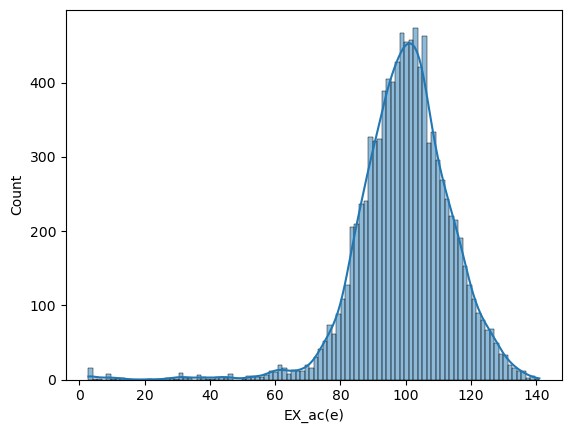

In [ ]:
sns.histplot(model_flux_samp['EX_ac(e)'], bins = 100, kde = True)

<Axes: xlabel='EX_lac_L(e)', ylabel='Count'>

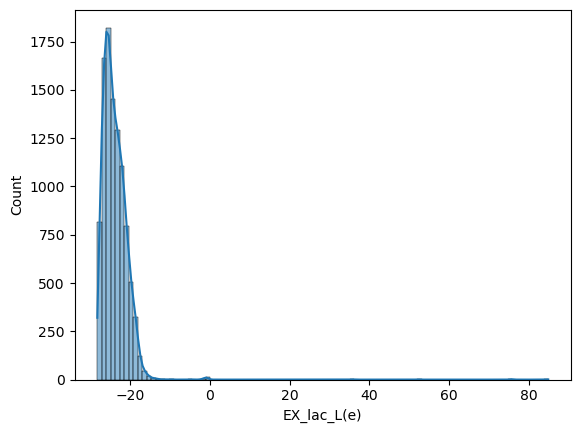

In [ ]:
sns.histplot(model_flux_samp['EX_lac_L(e)'], bins = 100, kde = True)

In [14]:
correct_model_dict_order['Bifidobacterium_longum'].summary(fva = 0.99)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmp18u7esz8.lp
Reading time = 0.03 seconds
: 2019 rows, 5525 columns, 21021 nonzeros
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpj6sl1p5c.lp
Reading time = 0.02 seconds
: 2019 rows, 5525 columns, 21021 nonzeros
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpl455bk9i.lp
Reading time = 0.02 seconds
: 20

Metabolite,Reaction,Flux,Range,C-Number,C-Flux
26dap_M[e],EX_26dap_M(e),0.03427,[-27.82; 0.1],7,1.58%
ade[e],EX_ade(e),5.994E-05,[0; 5.994E-05],5,0.00%
arg_L[e],EX_arg_L(e),0.02535,[0; 0.02535],6,1.00%
asn_L[e],EX_asn_L(e),0.02308,[-25.29; 2.6],4,0.61%
asp_L[e],EX_asp_L(e),0.09143,[-55.44; 0.4],4,2.41%
ca2[e],EX_ca2(e),0.0005365,[0.0005312; 0.0005365],0,0.00%
cl[e],EX_cl(e),0.0005365,[0.0005312; 0.0005365],0,0.00%
cobalt2[e],EX_cobalt2(e),0.0005365,[0.0005312; 0.0005365],0,0.00%
csn[e],EX_csn(e),5.941E-05,[0; 5.941E-05],4,0.00%
cu2[e],EX_cu2(e),0.0005365,[0.0005312; 0.0005365],0,0.00%


In [15]:
geo_fba = cobra.flux_analysis.geometric_fba(correct_model_dict_order['Bifidobacterium_longum'])

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpa2a9fl50.lp
Reading time = 0.03 seconds
: 2020 rows, 5525 columns, 26545 nonzeros
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpzyo0xf0z.lp
Reading time = 0.02 seconds
: 2020 rows, 5525 columns, 26545 nonzeros
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpw6wcb4sq.lp
Reading time = 0.02 seconds
: 20

/Users/haydengallo/miniconda3/envs/glv_fba/lib/python3.12/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
Could not get flux for reaction EX_trp_L(e), setting it to NaN. This is usually due to numerical instability.


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpbt4xeyct.lp
Reading time = 0.03 seconds
: 7544 rows, 8287 columns, 40355 nonzeros
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpej3h7clo.lp
Reading time = 0.03 seconds
: 7544 rows, 8287 columns, 40355 nonzeros
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2720828
Academic license 2720828 - for non-commercial use only - registered to ha___@umassmed.edu
Read LP format model from file /var/folders/08/_qc4td993cl748h7_329zsvc0000gn/T/tmpz8k3iaik.lp
Reading time = 0.02 seconds
: 75

/Users/haydengallo/miniconda3/envs/glv_fba/lib/python3.12/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
Could not get flux for reaction KARA1, setting it to NaN. This is usually due to numerical instability.
/Users/haydengallo/miniconda3/envs/glv_fba/lib/python3.12/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
Could not get flux for reaction SUCDimq, setting it to NaN. This is usually due to numerical instability.
Could not get flux for reaction SUCR, setting it to NaN. This is usually due to numerical instability.


AttributeError: Element 0 of a double array is Nan.

In [ ]:
geo_fba